In [ ]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv('../data/raw/ec2_cpu_utilization_24ae8d.csv', parse_dates=['timestamp'])
df = df.set_index('timestamp')

m = 288
tamanho_treino = int(len(df) * 0.8)
treino = df.iloc[:tamanho_treino].copy()
teste = df.iloc[tamanho_treino:].copy()

posicao_treino = np.arange(len(treino)) % m
perfil_sazonal = pd.Series(treino['value'].values, index=posicao_treino).groupby(level=0).mean()

posicao_global_teste = np.arange(tamanho_treino, tamanho_treino + len(teste)) % m
esperado_teste = perfil_sazonal.reindex(posicao_global_teste).values
residuo_teste = pd.Series(teste['value'].values - esperado_teste, index=teste.index)

with open('../data/labels/combined_windows.json') as f:
    labels = json.load(f)
windows = labels['realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv']
windows = [(pd.Timestamp(w[0]), pd.Timestamp(w[1])) for w in windows]

dentro_anomalia = pd.Series(False, index=teste.index)
for start, end in windows:
    dentro_anomalia |= (teste.index >= start) & (teste.index <= end)

In [3]:
JANELA = 24
sinal = residuo_teste.abs().rolling(window=JANELA, min_periods=JANELA).std()

In [4]:
sinal_normal = sinal[~dentro_anomalia].dropna()

limiar = sinal_normal.quantile(0.99)
print(f'Limiar definido: {limiar:.4f}')

Limiar definido: 0.2814


In [5]:
previsao_anomalia = (sinal > limiar).fillna(False)

In [6]:
verdadeiro_positivo = (previsao_anomalia & dentro_anomalia).sum()
falso_positivo = (previsao_anomalia & ~dentro_anomalia).sum()
falso_negativo = (~previsao_anomalia & dentro_anomalia).sum()

precisao = verdadeiro_positivo / (verdadeiro_positivo + falso_positivo)
recall = verdadeiro_positivo / (verdadeiro_positivo + falso_negativo)
f1 = 2 * (precisao * recall) / (precisao + recall)

print(f'Verdadeiros positivos: {verdadeiro_positivo}')
print(f'Falsos positivos:      {falso_positivo}')
print(f'Falsos negativos:      {falso_negativo}')
print(f'Precisão: {precisao:.3f}')
print(f'Recall:   {recall:.3f}')
print(f'F1-score: {f1:.3f}')

Verdadeiros positivos: 48
Falsos positivos:      4
Falsos negativos:      354
Precisão: 0.923
Recall:   0.119
F1-score: 0.211


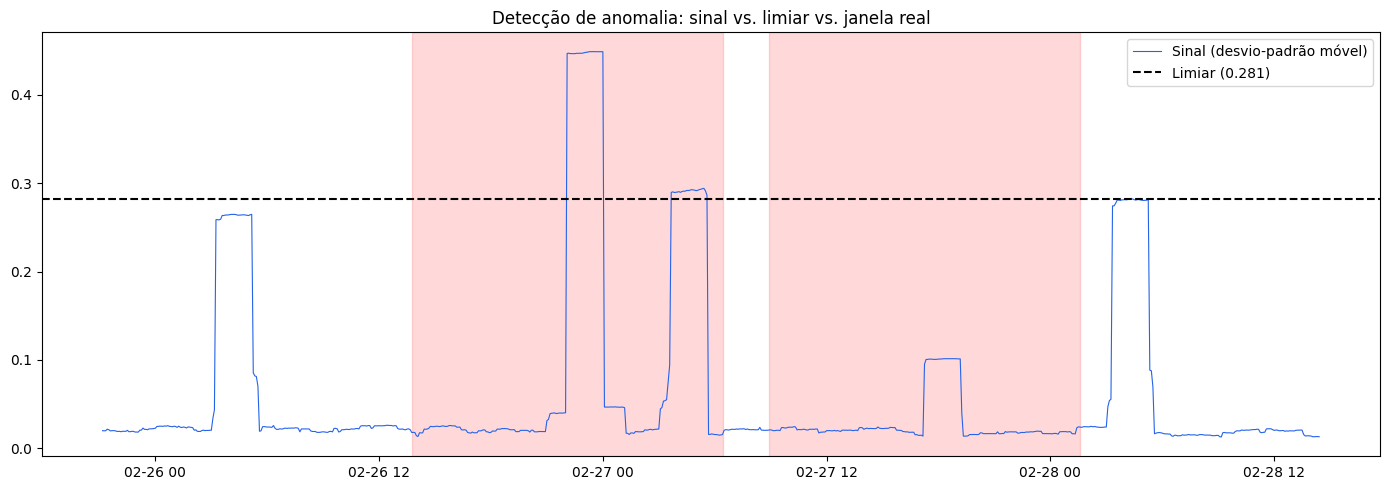

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sinal.index, sinal, linewidth=0.8, color='#2563eb', label='Sinal (desvio-padrão móvel)')
ax.axhline(limiar, color='black', linestyle='--', label=f'Limiar ({limiar:.3f})')
for start, end in windows:
    ax.axvspan(start, end, color='red', alpha=0.15)
ax.set_title('Detecção de anomalia: sinal vs. limiar vs. janela real')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
deteccoes = previsao_anomalia.astype(int)
mudanca_de_estado = deteccoes.diff().fillna(0)

inicio_alarmes = previsao_anomalia.index[mudanca_de_estado == 1].tolist()
fim_alarmes = previsao_anomalia.index[mudanca_de_estado == -1].tolist()

if len(inicio_alarmes) > len(fim_alarmes):
    fim_alarmes.append(previsao_anomalia.index[-1])

alarmes = list(zip(inicio_alarmes, fim_alarmes))
print(f'Total de alarmes detectados: {len(alarmes)}')
for a in alarmes:
    print(f'  {a[0]} -> {a[1]}')

Total de alarmes detectados: 3
  2014-02-26 22:05:00 -> 2014-02-27 00:05:00
  2014-02-27 03:40:00 -> 2014-02-27 05:40:00
  2014-02-28 04:10:00 -> 2014-02-28 04:30:00


In [9]:
def houve_sobreposicao(inicio_a, fim_a, inicio_b, fim_b):
    return inicio_a <= fim_b and inicio_b <= fim_a

alarmes_verdadeiros = []
alarmes_falsos = []

for inicio_alarme, fim_alarme in alarmes:
    sobrepoe_alguma_janela = any(
        houve_sobreposicao(inicio_alarme, fim_alarme, w_inicio, w_fim)
        for w_inicio, w_fim in windows
    )
    if sobrepoe_alguma_janela:
        alarmes_verdadeiros.append((inicio_alarme, fim_alarme))
    else:
        alarmes_falsos.append((inicio_alarme, fim_alarme))

janelas_detectadas = [
    w for w in windows
    if any(houve_sobreposicao(a_inicio, a_fim, w[0], w[1]) for a_inicio, a_fim in alarmes)
]

precisao_janela = len(alarmes_verdadeiros) / len(alarmes) if alarmes else 0
recall_janela = len(janelas_detectadas) / len(windows) if windows else 0
f1_janela = (
    2 * (precisao_janela * recall_janela) / (precisao_janela + recall_janela)
    if (precisao_janela + recall_janela) > 0 else 0
)

print(f'Total de janelas reais de anomalia: {len(windows)}')
print(f'Janelas detectadas: {len(janelas_detectadas)}')
print(f'Alarmes verdadeiros: {len(alarmes_verdadeiros)}')
print(f'Alarmes falsos: {len(alarmes_falsos)}')
print(f'Precisão: {precisao_janela:.3f}')
print(f'Recall:   {recall_janela:.3f}')
print(f'F1-score: {f1_janela:.3f}')

Total de janelas reais de anomalia: 2
Janelas detectadas: 1
Alarmes verdadeiros: 2
Alarmes falsos: 1
Precisão: 0.667
Recall:   0.500
F1-score: 0.571


In [ ]:
comparacao_avaliacoes = pd.DataFrame({
    'Ponto a ponto': [precisao, recall, f1],
    'Por janela/evento (estilo NAB)': [precisao_janela, recall_janela, f1_janela],
}, index=['Precisão', 'Recall', 'F1-score'])

comparacao_avaliacoes

,Ponto a ponto,Por janela/evento (estilo NAB)
Precisão,0.923077,0.666667
Recall,0.119403,0.500000
F1-score,0.211454,0.571429


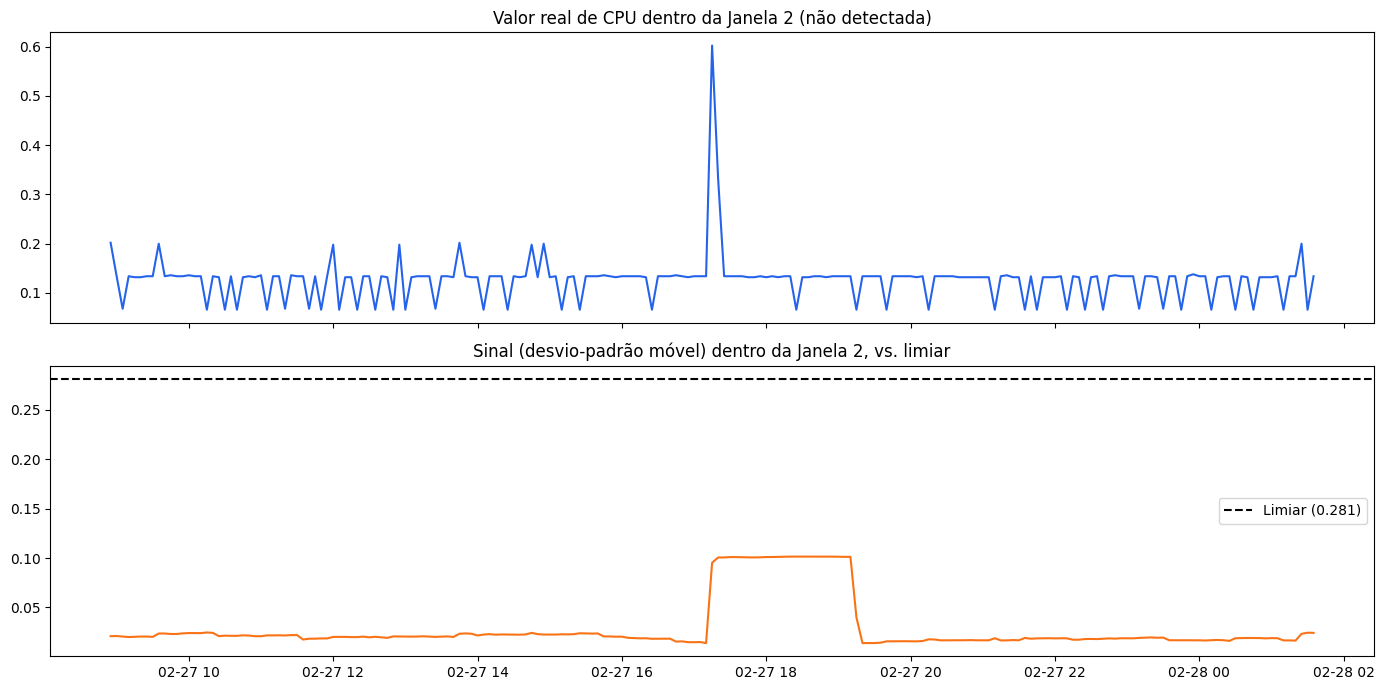

Máximo do sinal dentro da Janela 2: 0.1016
Limiar atual: 0.2814


In [11]:
janela_2_inicio, janela_2_fim = windows[1]

periodo_janela_2 = teste.loc[janela_2_inicio:janela_2_fim]
sinal_janela_2 = sinal.loc[janela_2_inicio:janela_2_fim]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(periodo_janela_2.index, periodo_janela_2['value'], color='#2563eb')
axes[0].set_title('Valor real de CPU dentro da Janela 2 (não detectada)')

axes[1].plot(sinal_janela_2.index, sinal_janela_2, color='#f97316')
axes[1].axhline(limiar, color='black', linestyle='--', label=f'Limiar ({limiar:.3f})')
axes[1].set_title('Sinal (desvio-padrão móvel) dentro da Janela 2, vs. limiar')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Máximo do sinal dentro da Janela 2: {sinal_janela_2.max():.4f}')
print(f'Limiar atual: {limiar:.4f}')